In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
from google.colab import files

uploaded = files.upload()

Saving archive (2).zip to archive (2) (1).zip


In [7]:
import zipfile
import os

zip_file = "archive (2) (1).zip"

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall("churn_data")

os.listdir("churn_data")

['WA_Fn-UseC_-Telco-Customer-Churn.csv']

In [8]:
import os

for root, dirs, files in os.walk("churn_data"):
    for file in files:
        print(os.path.join(root, file))

churn_data/WA_Fn-UseC_-Telco-Customer-Churn.csv


In [9]:
import pandas as pd

df = pd.read_csv(
    "churn_data/WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [10]:
df.shape

(7043, 21)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [12]:
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


In [13]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

print("Missing values:", df.isnull().sum().sum())
print("Duplicates:", df.duplicated().sum())
print("Shape:", df.shape)

Missing values: 0
Duplicates: 0
Shape: (7043, 21)


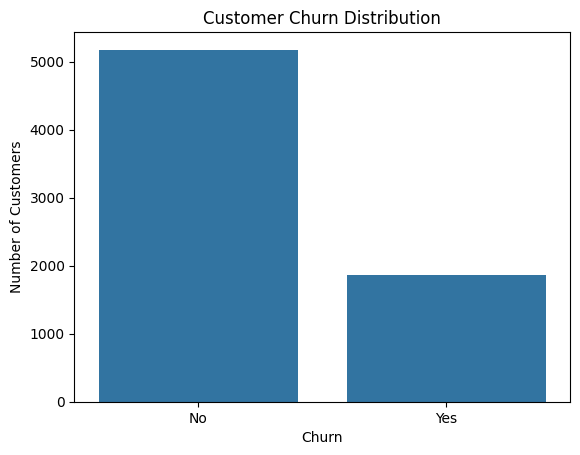

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

In [15]:
df["Churn"].value_counts(normalize=True) * 100

,proportion
Churn,
No,73.463013
Yes,26.536987


In [16]:
# Compare the percentage of churned and retained customers for each contract type
pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


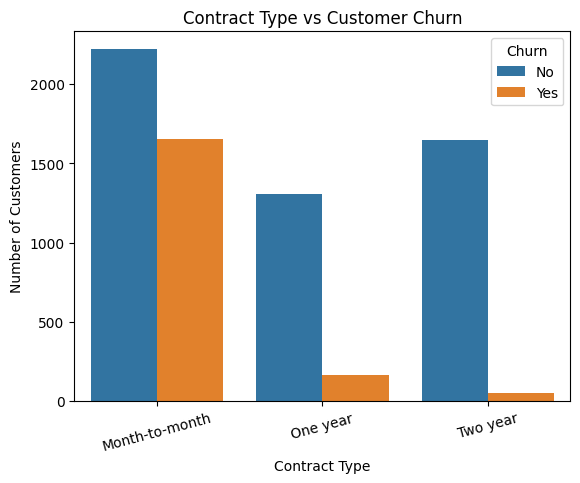

In [17]:
# Visualize customer churn across different contract types
sns.countplot(data=df, x="Contract", hue="Churn")

plt.title("Contract Type vs Customer Churn")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=15)
plt.show()

In [18]:
# Compare average customer tenure for churned and retained customers
df.groupby("Churn")["tenure"].mean()

,tenure
Churn,
No,37.569965
Yes,17.979133


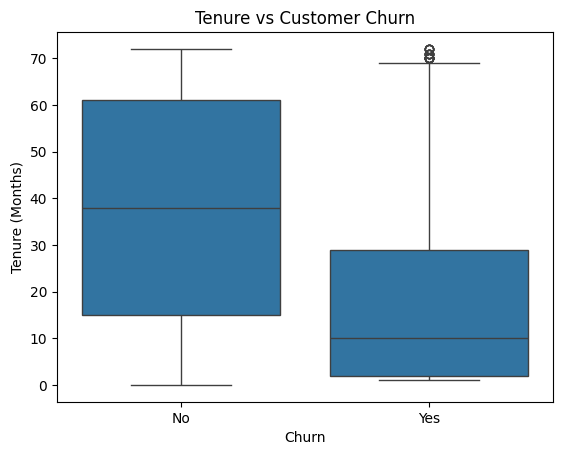

In [19]:
# Visualize the relationship between customer tenure and churn
sns.boxplot(data=df, x="Churn", y="tenure")

plt.title("Tenure vs Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")
plt.show()

In [20]:
# Compare average monthly charges for churned and retained customers
df.groupby("Churn")["MonthlyCharges"].mean()

,MonthlyCharges
Churn,
No,61.265124
Yes,74.441332


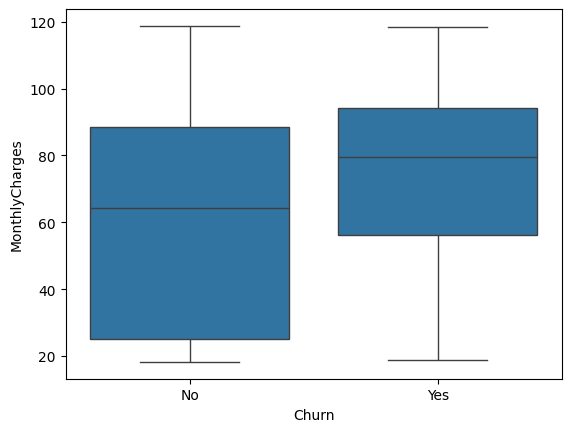

In [21]:
# Visualize monthly charges by churn status
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")
plt.show()

In [25]:
# Remove customer ID if it still exists
df = df.drop("customerID", axis=1, errors="ignore")

In [26]:
# Convert churn values into 1 and 0
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

In [27]:
# Convert categorical columns into numerical columns
df = pd.get_dummies(df, drop_first=True)

In [28]:
# Separate features and target
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [29]:
# Split data into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [30]:
# Check training and testing sizes
print(X_train.shape, X_test.shape)

(5634, 30) (1409, 30)


In [32]:
# Train Logistic Regression with more iterations
model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=2000)

In [33]:
# Predict churn for test data
y_pred = model.predict(X_test)

In [34]:
# Evaluate model performance
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8048261178140526
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



In [35]:
# Train a Random Forest model
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [36]:
# Predict churn using Random Forest
rf_pred = rf.predict(X_test)

In [37]:
# Evaluate Random Forest performance
print("Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Accuracy: 0.7863733144073811
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.62      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.77      0.79      0.78      1409



In [38]:
# Evaluate Random Forest performance
print("Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Accuracy: 0.7863733144073811
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.62      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.77      0.79      0.78      1409



In [39]:
# Find the most important features for predicting churn
importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

print(importance.head(10))

TotalCharges                      0.192096
tenure                            0.174733
MonthlyCharges                    0.168413
PaymentMethod_Electronic check    0.038771
InternetService_Fiber optic       0.038641
Contract_Two year                 0.030176
gender_Male                       0.028321
OnlineSecurity_Yes                0.028191
PaperlessBilling_Yes              0.025617
Partner_Yes                       0.023326
dtype: float64


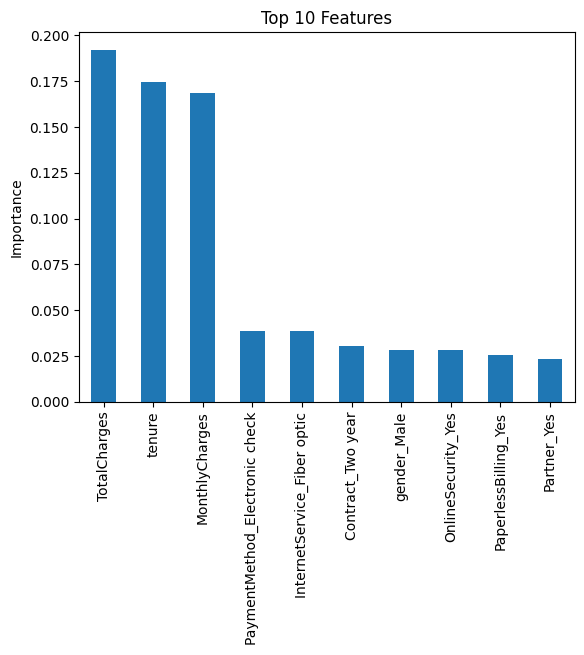

In [40]:
# Visualize the top 10 churn prediction features
importance.head(10).plot(kind="bar")
plt.title("Top 10 Features")
plt.ylabel("Importance")
plt.show()

In [41]:
# Compare the accuracy of both models
print("Logistic Regression:", accuracy_score(y_test, y_pred))
print("Random Forest:", accuracy_score(y_test, rf_pred))

Logistic Regression: 0.8048261178140526
Random Forest: 0.7863733144073811
